# Goal: Inspect the M1 vs M2 plot

In particular look at mass ratios (maybe fit them)

(LvS: 06-02-26)

In [1]:
import json
import numpy as np
import pandas as pd
import sys, os

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from scipy.stats import gaussian_kde
from scipy.optimize import curve_fit

from pathlib import Path

# Ensure project root is on sys.path so `import paths` finds the top-level paths.py
proj_root = Path('/Users/liekevanson/Documents/Projects/post_mt_review').resolve()
if str(proj_root) not in sys.path:
    sys.path.insert(0, str(proj_root))

from paths import DUMMY_CATALOG, MAIN_CATALOG, PLOTS_DIR, DOCS_DIR, LATEX_PLOT_DIR

file_path = MAIN_CATALOG


# Use mathtext (LaTeX-like without needing LaTeX)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['DejaVu Serif', 'Computer Modern Roman']
plt.rcParams['mathtext.fontset'] = 'cm'  # Computer Modern math font
plt.rcParams['font.size'] = 12


In [2]:
# Helper function to increase darkness of a color
def darken_color(color, factor=0.7):
    """
    Darken a color by multiplying its RGB values by a factor.
    color : str or tuple Color as hex string (e.g., '#FF0000') or RGB tuple
    factor : float Factor to darken by (0-1). Lower = darker. Default 0.7 
    Returns:
    str : Darkened color as hex string
    """
    import matplotlib.colors as mcolors
    # Convert to RGB if it's a hex string
    rgb = mcolors.to_rgb(color)
    # Multiply each channel by the factor
    darkened_rgb = tuple(c * factor for c in rgb)
    # Convert back to hex
    return mcolors.to_hex(darkened_rgb)



### Read json catalog into pandas table

In [3]:
# === Load JSON ===
def read_json_file(file_path):
    try:
        with open(file_path, "r") as f:
            data = json.load(f)
        return data
    except Exception as e:
        print(f"Error reading file: {e}")
        return None

def extract_triplet_array(data, key):
    """Return an (N,3) float array for the given triplet key, robust to None/NaN."""
    rows = []
    for entry in data:
        val = entry.get(key, None)
        if isinstance(val, (list, tuple, np.ndarray)) and len(val) == 3:
            try:
                # Convert None to np.nan before float conversion
                rows.append([
                    np.nan if val[0] is None else float(val[0]),
                    np.nan if val[1] is None else float(val[1]),
                    np.nan if val[2] is None else float(val[2])
                ])
            except (TypeError, ValueError):
                rows.append([np.nan, np.nan, np.nan])
        elif isinstance(val, (int, float)):
            # Scalar provided, treat as central value with unknown errors
            rows.append([np.nan, float(val), np.nan])
        else:
            rows.append([np.nan, np.nan, np.nan])
    return np.array(rows, dtype=float)

In [4]:
# Read data
data = read_json_file(str(MAIN_CATALOG))
if data is None:
    print("No data loaded. Exiting.")
    exit(1)


In [5]:
# Extract triplet columns once for efficiency/consistency
RA_arr = extract_triplet_array(data, 'RA')
Dec_arr = extract_triplet_array(data, 'Dec')
period_arr = extract_triplet_array(data, 'Period')
ecc_arr = extract_triplet_array(data, 'Eccentricity')
m1_arr = extract_triplet_array(data, 'M1')
m2_arr = extract_triplet_array(data, 'M2')

# Build a single DataFrame with central values and errors
catalog_df = pd.DataFrame({
    'System Name': [entry.get('System Name', '') for entry in data],
    'RA': RA_arr[:, 1],
    'Dec': Dec_arr[:, 1],
    'Period': period_arr[:, 1],
    'Period_err_minus': period_arr[:, 0],
    'Period_err_plus': period_arr[:, 2],
    'Eccentricity': ecc_arr[:, 1],
    'Eccentricity_err_minus': ecc_arr[:, 0],
    'Eccentricity_err_plus': ecc_arr[:, 2],
    'M1': m1_arr[:, 1],
    'M1_err_minus': m1_arr[:, 0],
    'M1_err_plus': m1_arr[:, 2],
    'M2': m2_arr[:, 1],
    'M2_err_minus': m2_arr[:, 0],
    'M2_err_plus': m2_arr[:, 2],
    'obs_type_1': [entry.get('obs_type_1', '') for entry in data],
    'obs_type_2': [entry.get('obs_type_2', '') for entry in data],
    'evol_type_1': [entry.get('evol_type_1', '') for entry in data],
    'evol_type_2': [entry.get('evol_type_2', '') for entry in data],
    'system_class': [entry.get('system_class', 'None') for entry in data],
    'Simbad': [entry.get('Simbad', None) for entry in data]
})

In [6]:
display(catalog_df)

,System Name,RA,Dec,Period,Period_err_minus,Period_err_plus,Eccentricity,Eccentricity_err_minus,Eccentricity_err_plus,M1,...,M1_err_plus,M2,M2_err_minus,M2_err_plus,obs_type_1,obs_type_2,evol_type_1,evol_type_2,system_class,Simbad
0,Cl* NGC 188 PKM 451,8.700020,85.540940,722.000000,4.000000e+00,4.000000e+00,0.34,0.03,0.03,NaN,...,NaN,NaN,NaN,NaN,None,None,MS,WD,Blue straggler binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
1,Cl* NGC 188 PKM 1888,13.631330,85.535900,2240.000000,3.000000e+01,3.000000e+01,0.21,0.04,0.04,NaN,...,NaN,NaN,NaN,NaN,None,None,MS,WD,Blue straggler binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
2,Cl* NGC 188 PKM 2679,6.685930,85.310000,1033.000000,8.000000e+00,8.000000e+00,0.07,0.05,0.05,NaN,...,NaN,NaN,NaN,NaN,None,None,MS,WD,Blue straggler binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
3,Cl* NGC 188 PKM 4348,10.923210,85.221480,1168.000000,8.000000e+00,8.000000e+00,0.09,0.05,0.05,NaN,...,NaN,NaN,NaN,NaN,None,None,MS,WD,Blue straggler binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
4,Cl* NGC 188 PKM 4540,11.326540,85.322200,3030.000000,7.000000e+01,7.000000e+01,0.36,0.07,0.07,NaN,...,NaN,NaN,NaN,NaN,None,None,MS,WD,Blue straggler binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4678,UCAC4 495-142916,297.473341,8.904363,0.748668,1.600000e-06,1.600000e-06,NaN,NaN,NaN,1.69,...,0.07,0.31,0.07,0.07,None,pre-He WD,MS,WD,EL CVn,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
4679,CRTS J225539.4+342138,118.713529,34.360512,0.571785,3.000000e-07,3.000000e-07,NaN,NaN,NaN,1.40,...,0.04,0.26,0.04,0.04,None,pre-He WD,MS,WD,EL CVn,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
4680,UCAC4 646-116578,123.282814,39.139678,0.766129,3.800000e-06,3.800000e-06,NaN,NaN,NaN,1.60,...,0.08,0.16,0.05,0.05,None,pre-He WD,MS,WD,EL CVn,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
4681,ZTF J225755.64+310133.7,127.228463,31.026046,0.688416,4.000000e-07,4.000000e-07,NaN,NaN,NaN,1.65,...,0.06,0.29,0.04,0.04,None,pre-He WD,MS,WD,EL CVn,https://simbad.cds.unistra.fr/simbad/sim-coo?C...


In [7]:
# Create discrete color map between 
WD_cmap = mcolors.LinearSegmentedColormap.from_list('custom_gradient', ['#e6cfd9', '#a5678e'])
WDcolors = [mcolors.rgb2hex(WD_cmap(i)) for i in np.linspace(0, 1, 7)]

stripped_star_cmap = mcolors.LinearSegmentedColormap.from_list('custom_gradient', ['#82c9ed', '#366de2']) #BDDEF4 #1b478e
strippedstar_colors = [mcolors.rgb2hex(stripped_star_cmap(i)) for i in np.linspace(0, 1, 4)]

compact_object_cmap = mcolors.LinearSegmentedColormap.from_list('custom_gradient', ['#bde256', '#0c9e27'])
compact_obj_colors = [mcolors.rgb2hex(compact_object_cmap(i)) for i in np.linspace(0, 1, 4)]

SYSTEM_CLASS_MAP = {
    # Binaries containing white dwarfs
    'WD binary':{'Astrometric WD + MS': {'color': WDcolors[0], 'symbol': 'circle'},                  # light purple
    'Spectroscopic WD + MS': {'color': WDcolors[1], 'symbol': 'cross-dot'},                  # light purple
    'WD + MS': {'color': WDcolors[2], 'symbol': 'pentagon'},                  # left over ones (come from Krukow paper 2021ApJ...920...86K)
    'Blue straggler binary': {'color': WDcolors[3], 'symbol': 'hourglass'}, # yellow
    'Chemically Peculiar': {'color': WDcolors[4], 'symbol': 'square'}, # gray  
    },

    'Transition to WD':{'EL CVn': {'color': '#FF6692', 'symbol': 'star'},         # orange
    'post AGB': {'color': '#ea4d4d', 'symbol': 'cross'},           # coral/red
    },

    # Binaries w. non-degenerate components
    'Ongoing RLOF': {'Contact binary': {'color': '#eda45c', 'symbol': 'triangle-up'},           # orange
    'Algol': {'color': '#d65906', 'symbol': 'diamond'},                   # maroon
    },

    'Stripped component': {'Hot subdwarf': {'color': strippedstar_colors[0], 'symbol': 'pentagon-open'},             # UV purple
    'Stripped star': {'color': strippedstar_colors[1], 'symbol': 'x'},  # muted green
    'WR binary': {'color': strippedstar_colors[2], 'symbol': 'triangle-up'},       # blue
    },

    # Binaries containing neutron stars or black holes
    'CO binary': {'pulsar binary': {'color': compact_obj_colors[0], 'symbol': 'diamond-tall'},           # lime green
    'high-mass XRB': {'color': compact_obj_colors[1], 'symbol': 'square'},             # muted green
    'Spectroscopic compact object': {'color': compact_obj_colors[2], 'symbol': 'x'},  # yellow green
    'Astrometric compact object': {'color': compact_obj_colors[3], 'symbol': 'circle-open'},  # muted green
    },
}

In [8]:
# Helper function to increase darkness of a color
def darken_color(color, factor=0.7):
    """
    Darken a color by multiplying its RGB values by a factor.
    
    Parameters:
    -----------
    color : str or tuple
        Color as hex string (e.g., '#FF0000') or RGB tuple
    factor : float
        Factor to darken by (0-1). Lower = darker. Default 0.7
        
    Returns:
    --------
    str : Darkened color as hex string
    """
    import matplotlib.colors as mcolors
    
    # Convert to RGB if it's a hex string
    rgb = mcolors.to_rgb(color)
    
    # Multiply each channel by the factor
    darkened_rgb = tuple(c * factor for c in rgb)
    
    # Convert back to hex
    return mcolors.to_hex(darkened_rgb)

# Example usage:
# darker_green = darken_color(mass_colors[0], factor=0.6)
# ax.plot(x, y, color=darker_green)

# Plot M1 vs M2 per category: linear x and y

Ongoing RLOF:
  M2 = 0.697±0.026 * M1 + -1.171±0.297
  Mass ratio q = M2/M1 ≈ 0.697
Stripped component:
  M2 = 0.646±0.080 * M1 + 1.532±1.131
  Mass ratio q = M2/M1 ≈ 0.646
CO binary:
  M2 = 0.073±0.064 * M1 + 2.495±0.895
  Mass ratio q = M2/M1 ≈ 0.073


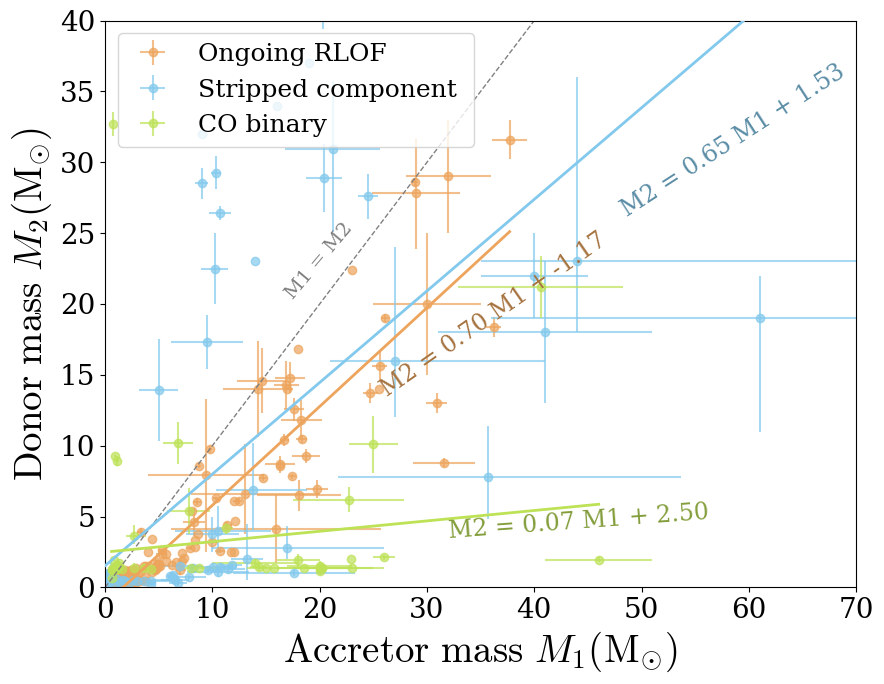

In [9]:
fig, ax = plt.subplots(figsize=(9, 7))

plot_df = catalog_df.copy()

###### Handling errors ######
# Fill NaN errors with zero
plot_df['M1_err_minus'] = plot_df['M1_err_minus'].fillna(0)
plot_df['M1_err_plus'] = plot_df['M1_err_plus'].fillna(0)
plot_df['M2_err_minus'] = plot_df['M2_err_minus'].fillna(0)
plot_df['M2_err_plus'] = plot_df['M2_err_plus'].fillna(0)

# Loop over categories instead of individual system classes
for category, systems in SYSTEM_CLASS_MAP.items():
    if category in ['WD binary', 'Transition to WD']: # these don't show on the linear M plot
        continue
    else:
        # Combine all system classes in this category
        system_classes_in_category = list(systems.keys())
        subset = plot_df[plot_df['system_class'].isin(system_classes_in_category)]
        log_periods = np.log10(subset['Period'].dropna())
        
        first_system_color = list(systems.values())[0]['color']

        ###### Actual plotting ######
        ax.errorbar(subset['M1'], (subset['M2']),
                    xerr=[subset['M1_err_minus'], subset['M1_err_plus']], 
                    yerr=[subset['M2_err_minus'], subset['M2_err_plus']], zorder = 0,
                    fmt='o', c=first_system_color, alpha=0.7,
                    label=f"{category} ")  

        ###### Add polynomal fit ######

        fit_df = subset.dropna(subset=['M1', 'M2'])
        # Define linear function
        def linear_func(x, a, b):
            return a * x + b
        
        # Perform curve_fit
        popt, pcov = curve_fit(linear_func, fit_df['M1'], fit_df['M2'])

        # Generate smooth curve for plotting
        x_fit = np.linspace(fit_df['M1'].min(), fit_df['M1'].max(), 100)
        y_fit = linear_func(x_fit, *popt)
        
        # Plot the fit
        ax.plot(x_fit, y_fit, color=first_system_color, linewidth=2, zorder=10)
        
        # Print results
        a, b = popt
        perr = np.sqrt(np.diag(pcov))
        a_err, b_err = perr
        print(f"{category}:")
        print(f"  M2 = {a:.3f}±{a_err:.3f} * M1 + {b:.3f}±{b_err:.3f}")
        print(f"  Mass ratio q = M2/M1 ≈ {a:.3f}")

        # Annotate the plot with the fit equation     
        ax.text(x_fit[-5], y_fit[-5]-(0.2*y_fit[-5]), f'M2 = {a:.2f} M1 + {b:.2f}', rotation = np.degrees(np.arctan(a)), 
                ha = 'center', va = 'center', fontsize=17, color=darken_color(first_system_color,factor = 0.7), zorder=15)   

# Show x=y line for reference
ax.plot(np.linspace(0,70), np.linspace(0,70), color='gray', linestyle='--', linewidth=1)
# Annotate x=y line
ax.text(20, 23, 'M1 = M2', color='gray', fontsize=14, ha='center', va='center', rotation=50)


# Plot formatting
# Set tick labels to be larger and use mathtext for the x-axis
plt.xlim(0,70)
plt.ylim(0,40)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel('$\mathrm{Accretor \ mass} \ M_1 \mathrm{(M_{\odot})}$', fontsize=28)
plt.ylabel('$\mathrm{Donor \ mass} \ M_2 \mathrm{(M_{\odot})}$', fontsize=28)
plt.legend(loc='upper left', fontsize=18, ncols =1)
plt.tight_layout()
plt.savefig(LATEX_PLOT_DIR / 'M1_M2_lin_fit.pdf')
plt.savefig(PLOTS_DIR / 'M1_M2_lin_fit.pdf')
plt.show()

# Plot M1 vs M2 per category: log10 x and y

WD binary:
 log M2 = -0.085±0.009 * log M1 + -0.234±0.002
Transition to WD:
 log M2 = 0.969±0.296 * log M1 + -0.913±0.070


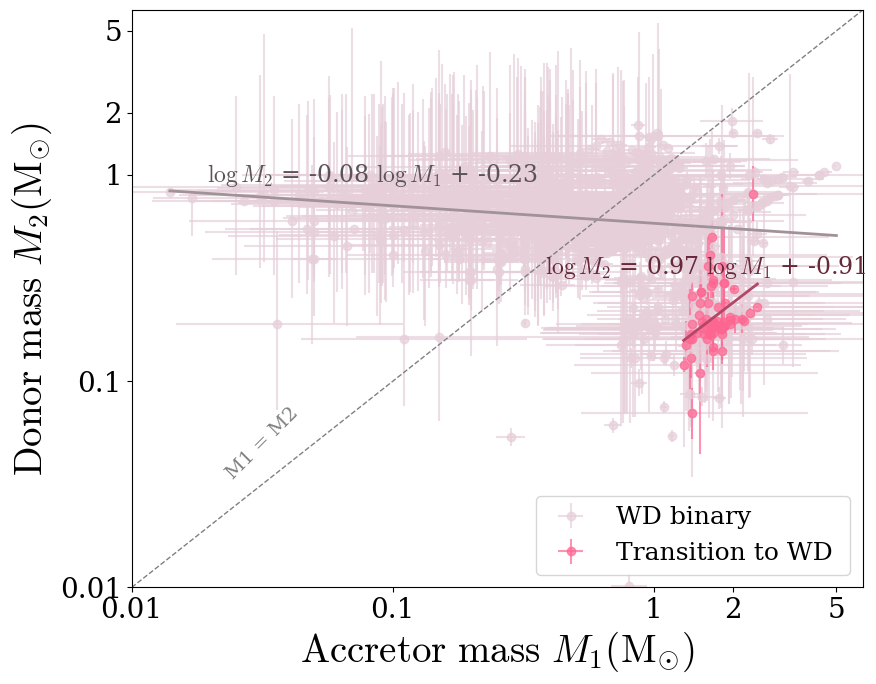

In [10]:
fig, ax = plt.subplots(figsize=(9, 7))

plot_df = catalog_df.copy()
plot_df['log_M1'] = np.log10(plot_df['M1'])
plot_df['log_M2'] = np.log10(plot_df['M2'])

###### Handling errors ######
# Propagate errors for logM1 and logM2: d(log M) = 1/ln(10) *  dM /M 
M1_err_minus_log = plot_df['M1_err_minus'] / (plot_df['M1'] * np.log(10))
M1_err_plus_log = plot_df['M1_err_plus'] / (plot_df['M1'] * np.log(10))
M2_err_minus_log = plot_df['M2_err_minus'] / (plot_df['M2'] * np.log(10))
M2_err_plus_log = plot_df['M2_err_plus'] / (plot_df['M2'] * np.log(10))

# Fill NaN errors with zero
plot_df['M1_err_minus_log'] = M1_err_minus_log.fillna(0)
plot_df['M1_err_plus_log'] = M1_err_plus_log.fillna(0)
plot_df['M2_err_minus_log'] = M2_err_minus_log.fillna(0)
plot_df['M2_err_plus_log'] = M2_err_plus_log.fillna(0)

# Loop over categories instead of individual system classes
for category, systems in SYSTEM_CLASS_MAP.items():
    if category not in ['WD binary', 'Transition to WD']: # these don't show on the linear M plot
        continue
    else:
        # Combine all system classes in this category
        system_classes_in_category = list(systems.keys())
        subset = plot_df[plot_df['system_class'].isin(system_classes_in_category)]
        log_periods = np.log10(subset['Period'].dropna())
        
        first_system_color = list(systems.values())[0]['color']

        ###### Actual plotting ######
        ax.errorbar(subset['log_M1'], (subset['log_M2']),
                    xerr=[subset['M1_err_minus_log'], subset['M1_err_plus_log']], 
                    yerr=[subset['M2_err_minus_log'], subset['M2_err_plus_log']], zorder = 0,
                    fmt='o', c=first_system_color, alpha=0.7,
                    label=f"{category} ")  


        ###### Add polynomal fit ######
        fit_df = subset.dropna(subset=['log_M1', 'log_M2'])
        # Define linear function
        def linear_func(x, a, b):
            return a * x + b
        
        # Perform curve_fit
        popt, pcov = curve_fit(linear_func, fit_df['log_M1'], fit_df['log_M2']) 
        # Generate smooth curve for plotting
        x_fit = np.linspace(fit_df['log_M1'].min(), fit_df['log_M1'].max(), 100)
        y_fit = linear_func(x_fit, *popt)
        
        # Plot the fit
        ax.plot(x_fit, y_fit, color=darken_color(first_system_color,factor = 0.7), linewidth=2, zorder=10)
        
        # Print results
        a, b = popt
        perr = np.sqrt(np.diag(pcov))
        a_err, b_err = perr
        print(f"{category}:")
        print(f" log M2 = {a:.3f}±{a_err:.3f} * log M1 + {b:.3f}±{b_err:.3f}")

        # Annotate the plot with the fit equation     
        ax.text(x_fit[30], y_fit[30]-(0.5*y_fit[-5]), f'$\log M_2$ = {a:.2f} $\log M_1$ + {b:.2f}', rotation = 0,#np.degrees(np.arctan(a)), 
                ha = 'center', va = 'center', fontsize=17, color=darken_color(first_system_color,factor = 0.4), zorder=15)   


# Show x=y line for reference
ax.plot(np.linspace(-2,1), np.linspace(-2,1), color='gray', linestyle='--', linewidth=1)
ax.text(-1.5, -1.3, 'M1 = M2', color='gray', fontsize=14, ha='center', va='center', rotation=45)

# Write x and y ticks in not log format
ax.set_xticks([-2, -1, 0, np.log10(2),np.log10(5)])
ax.set_xticklabels(['0.01', '0.1', '1', '2', '5'], fontsize=20) 
ax.set_yticks([-2, -1, 0, np.log10(2),np.log10(5)])
ax.set_yticklabels(['0.01', '0.1', '1', '2', '5'], fontsize=20)

# Plot formatting
plt.xlim(-2,0.8)
plt.ylim(-2,0.8)
plt.xlabel('$\mathrm{Accretor \ mass} \ M_1 \mathrm{(M_{\odot})}$', fontsize=28)
plt.ylabel('$\mathrm{Donor \ mass} \ M_2 \mathrm{(M_{\odot})}$', fontsize=28)
plt.legend(loc='lower right', fontsize=18, ncols =1)
plt.tight_layout()
plt.savefig(LATEX_PLOT_DIR / 'M1_M2_WD_transition_log_fit.pdf')
plt.savefig(PLOTS_DIR / 'M1_M2_WD_transition_log_fit.pdf')
plt.show()